# **Analyze Financial Data with Python Capstone**

##### By Faatimah Majothi

### Project Goals

The purpose of this capstone project is to practice accessing and downloading financial data, calculating financial statistics to understand the individual performance of an asset and how groups of assets are related, and how to allocate investments across assets for optimal performance.
In this project, I will create a presentation that showcases a portfolio of stocks that I recommend my client invest in, and provide the weights at which they should invest in each stock depending on their risk preference.

**Note: All information in this project is for research purposes only, and is not recommended investment advice. Investing is at your own risk.**

## Stocks Overview

The following stocks will be analysed in this project:

|**NASDAQ**   |**STOCK COMPANY**                |
|-------------|---------------------------------|
|AXIA         |AXIA Energia SA                  |
|BEPC         |Brookfield Renewable Corporation |
|VGAS         |Verde Clean Fuels, Inc.          |
|CWEN         |Clearway Energy, Inc.            |
|RNW          |ReNew Energy Global Plc          |
|FLNC         |Fluence Energy, Inc.             |
|AGIG         |Abundia Global Impact Group Inc. |

More information on each stock is provided below.
- **AXIA Energia SA**: This Brazil-based company generates electricity through hydroelectric, thermoelectric, nuclear, wind, and solar plants.
- **Brookfield Renewable Corporation**: The company’s portfolio of renewable power and sustainable solution assets consists of hydroelectric, wind, utility-scale solar, distributed generation, pumped storage, carbon capture and storage, cogeneration, biomass, and eFuels.
- **Verde Clean Fuels, Inc.**: A clean fuels company that focuses on the deployment of liquid fuels processing technology through development of commercial production plants in the US.
- **Clearway Energy, Inc.**: Operates through Flexible Generation and Renewables & Storage segments in the US. The company’s portfolio is made up of wind, solar, and battery energy storage systems; and  dispatchable combustion-based power generation assets included in the Flexible Generation segment that provide critical grid reliability services.
- **ReNew Energy Global Plc**: This company, together with its subsidiaries, engages in the generation of power through non-conventional and renewable energy sources in India. It operates through five segments: Wind Power, Solar Power, Hydro Power, Transmission Line, and Manufacturing segments.
- **Fluence Energy, Inc.**: Through its subsidiaries, the company provides energy storage and optimization software for renewables and storage applications in the Americas, the Asia Pacific, Europe, the Middle East, and Africa. It sells energy storage products with integrated hardware, software, and digital intelligence.
- **Abundia Global Impact Group Inc.**: This independent renewable and clean energy project developer, power producer, and asset operator company focuses on solar photovoltaic power generation projects, battery energy storage systems, and EV-charging projects, grid connected solar PV electricity power plants and battery energy storage system.

All API data and company information displayed here is sourced from [stockanalysis.com](https://stockanalysis.com/stocks/industry/utilities-renewable/).

# **Inititialising Libraries and Data**

In [1]:
# Import libraries

import pandas as pd
import numpy as np
import seaborn as sns
from datetime import datetime
import yfinance as yf
import cvxopt as opt
from cvxopt import blas, solvers
import matplotlib.pyplot as plt

In [2]:
# Initialise data

symbols = ['AXIA', 'BEPC', 'VGAS', 'CWEN', 'RNW', 'FLNC', 'AGIG']
start_date = datetime(2024, 1, 1)
stock_data = yf.download(symbols, start=start_date, auto_adjust = True) 

# Select closing price data

closing_price = stock_data['Close']
closing_price.head()

[*********************100%***********************]  7 of 7 completed


Ticker,AGIG,AXIA,BEPC,CWEN,FLNC,RNW,VGAS
Date,,,,,,,
2024-01-02,17.900000,7.481393,26.105389,23.837700,23.850000,7.55,2.31
2024-01-03,18.400000,7.463770,26.402550,23.530853,22.480000,7.58,2.32
2024-01-04,18.000000,7.402085,26.249466,23.522085,21.879999,7.52,2.39
2024-01-05,17.500000,7.472581,26.690710,23.539619,21.500000,7.51,2.31
2024-01-08,16.700001,7.446145,27.546181,23.890303,21.990000,7.52,2.31


### Adjusted Closing Price Over Time

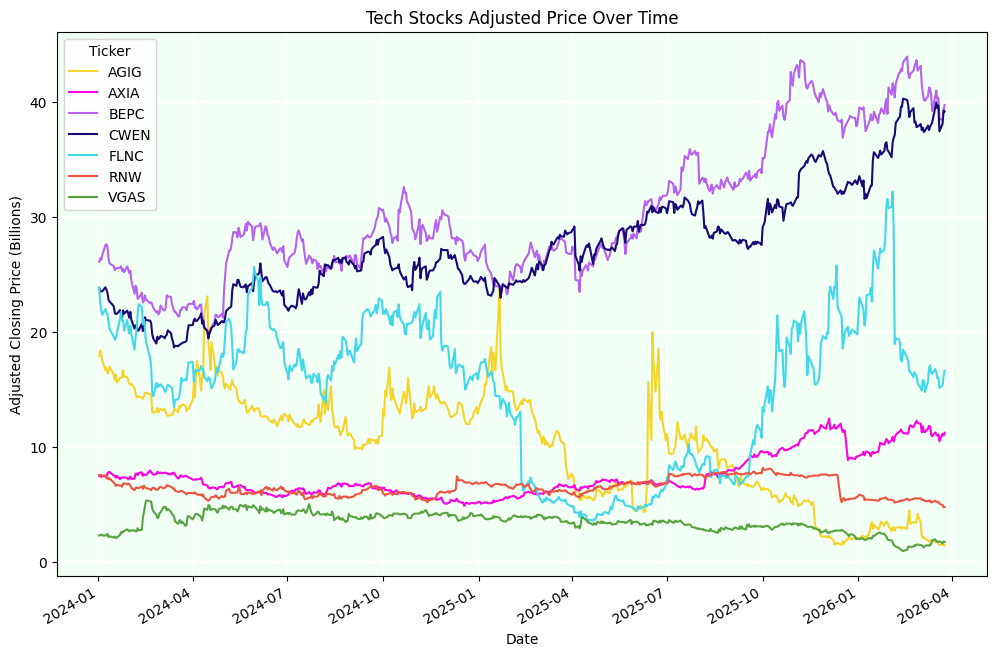

In [3]:
# Set colors for each stock

stock_cpalette = {
    'AXIA': '#FF00E6',
    'BEPC': '#B762F0', 
    'VGAS': '#58A341', 
    'CWEN': '#1A0878', 
    'RNW': '#EB5642', 
    'FLNC': '#42D7EB',
    'AGIG': '#F5D52C'   
}
palette = sns.color_palette([stock_cpalette[s] for s in symbols])
sns.set_palette(palette)

# Plot the adjusted closing price over time

closing_price.plot(figsize=(12,8), color=stock_cpalette)
plt.xlabel('Date')
plt.ylabel('Adjusted Closing Price (Billions)')
plt.title('Tech Stocks Adjusted Price Over Time')
plt.grid(which='both', axis='both', color='white', linewidth=1.5)
plt.gca().set_facecolor('#F2FFF4')
plt.savefig('stocksadjpriceovertime.png', bbox_inches='tight')
plt.show()
plt.close()

Brookfield Renewable Corporation (**`BEPC`**) and Clearway Energy, Inc. (**`CWEN`**) have both seen a **`rise`** in stock prices over the last two years. Fluence Energy, Inc. (**`FLNC`**) stock closing prices **rose steeply** in the beginning of 2026 before **plummeting** around February. Abundia Global Impact Group Inc. (**`AGIG`**) in particular has seen a **decline** in stock closing prices over the last two years, rising sharply around June 2025 after a steep decline around .

# **Stock Returns and Volatility**

### Daily Simple Rate of Return Over Time

In [4]:
# Calculate the simple daily rate of return (RoR)

stock_data_daily_returns = stock_data['Close'].pct_change()
stock_data_daily_returns.head()

Ticker,AGIG,AXIA,BEPC,CWEN,FLNC,RNW,VGAS
Date,,,,,,,
2024-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-03,0.027933,-0.002356,0.011383,-0.012872,-0.057442,0.003973,0.004329
2024-01-04,-0.021739,-0.008265,-0.005798,-0.000373,-0.026690,-0.007916,0.030172
2024-01-05,-0.027778,0.009524,0.016810,0.000745,-0.017367,-0.001330,-0.033473
2024-01-08,-0.045714,-0.003538,0.032051,0.014898,0.022791,0.001332,0.000000


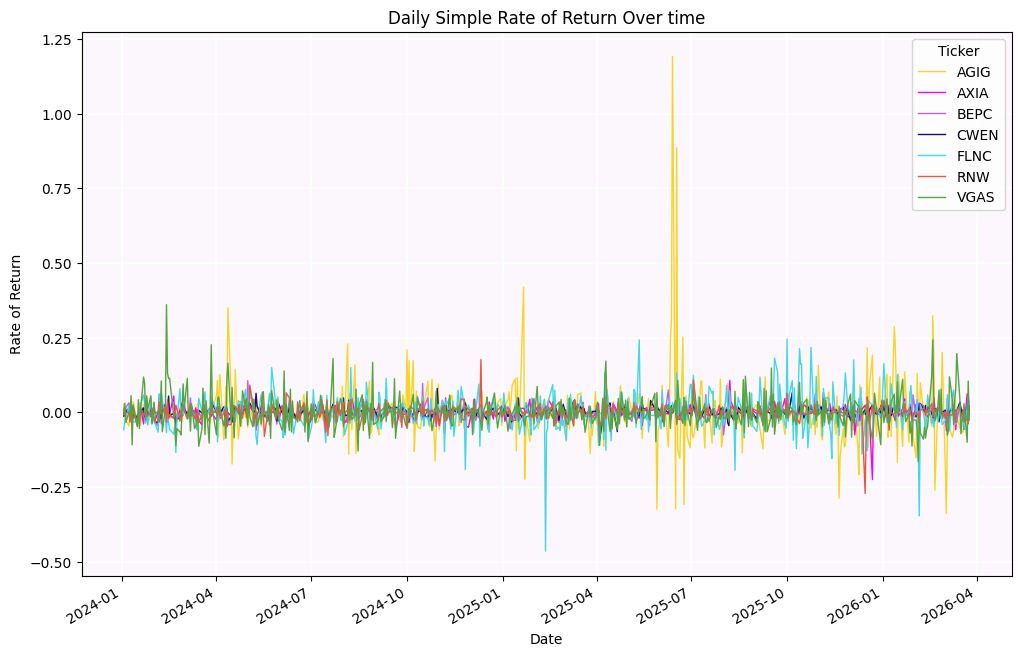

In [5]:
# Plot simple daily RoR

stock_data_daily_returns.plot(figsize=(12,8), linewidth=1, color=stock_cpalette)
plt.xlabel('Date')
plt.ylabel('Rate of Return')
plt.title('Daily Simple Rate of Return Over time')
plt.grid(which='both', axis='both', color='white', linewidth=1.25)
plt.gca().set_facecolor('#FCF7FC') 
plt.savefig('dailysimpleRoR.png', bbox_inches='tight')
plt.show()
plt.close()

At first glance, Abundia Global Impact Group Inc. (**`AGIG`**) shows the **largest swings** in daily rate of return, indicating that it is the most volatile and risky stock. Around February 2025, Fluence Energy, Inc. (**`FLNC`**) experienced the **largest single-day loss** on the graph, with a daily rate of return close to -0.5. To get a clearer look at each stock, the daily simple RoR over time for each is plotted seperately.

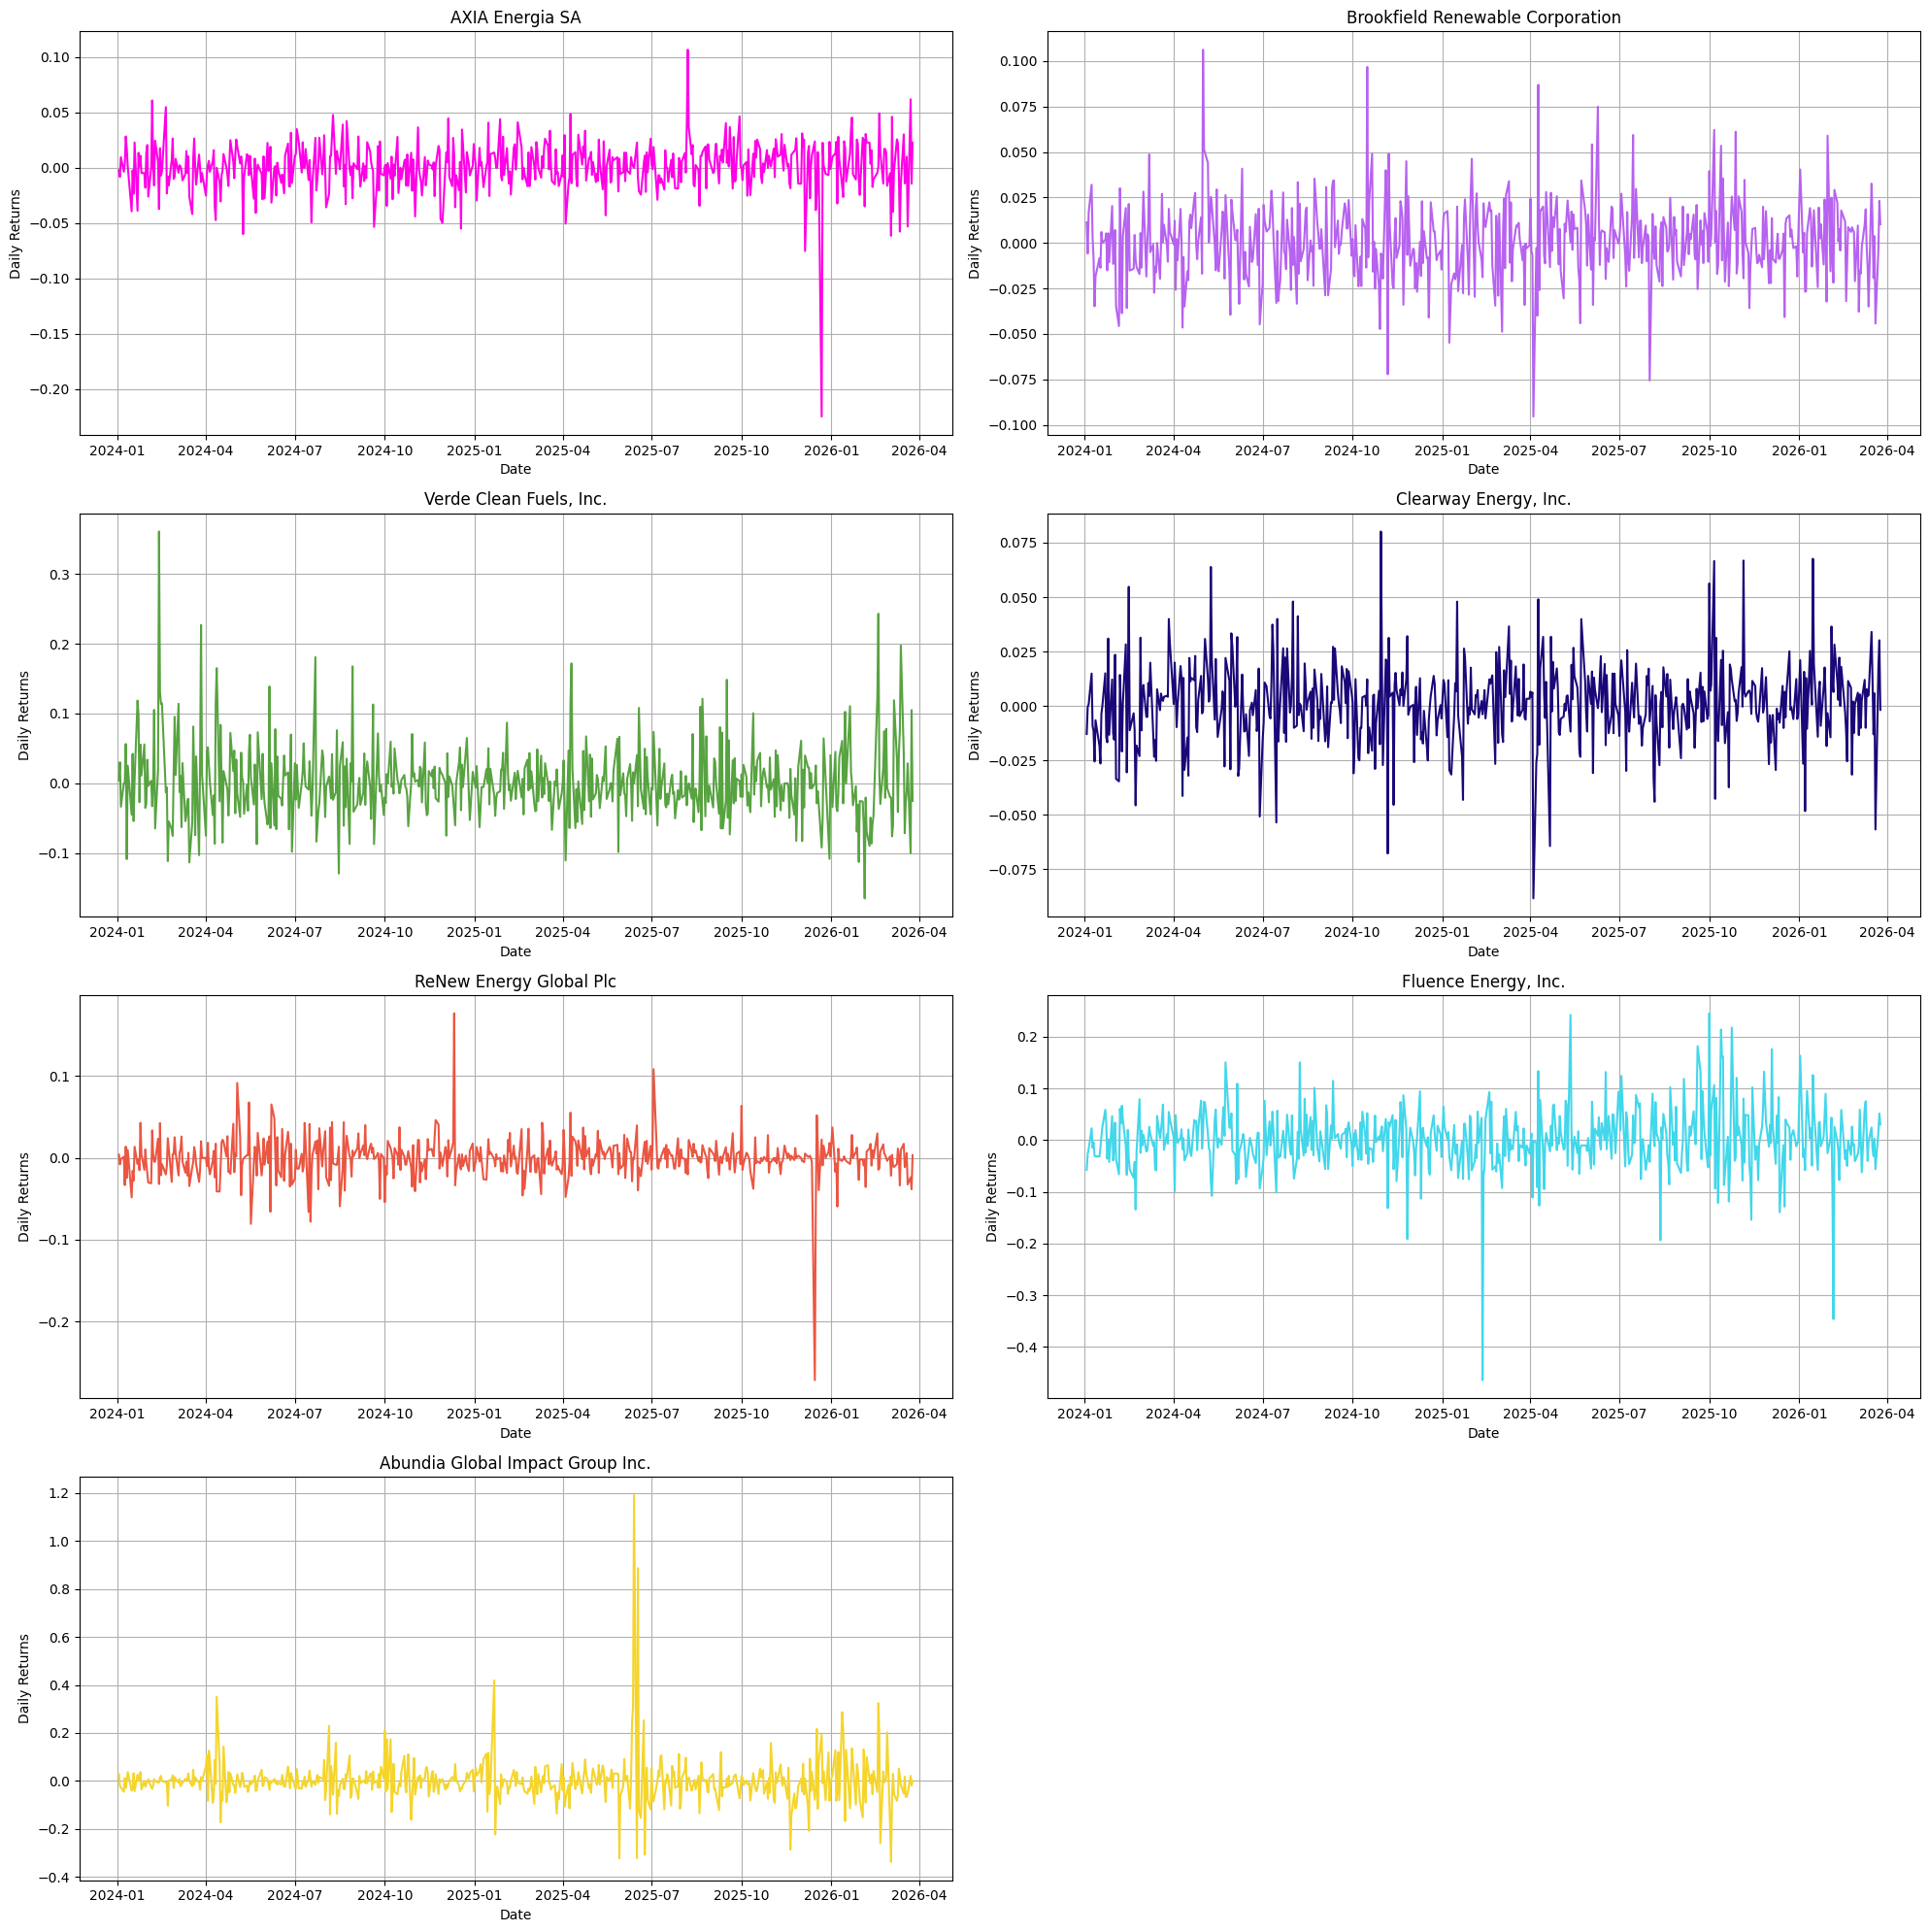

In [6]:
# Plot subplots

fig = plt.figure(figsize=(20,20))

ax1 = fig.add_subplot(421)
ax2 = fig.add_subplot(422)
ax3 = fig.add_subplot(423)
ax4 = fig.add_subplot(424)
ax5 = fig.add_subplot(425)
ax6 = fig.add_subplot(426)
ax7 = fig.add_subplot(427)

ax1.plot(stock_data_daily_returns['AXIA'], color=stock_cpalette['AXIA'])
ax1.set_title('AXIA Energia SA')
ax1.set_xlabel('Date')
ax1.set_ylabel('Daily Returns')
ax1.grid(True)

ax2.plot(stock_data_daily_returns['BEPC'], color=stock_cpalette['BEPC'])
ax2.set_title('Brookfield Renewable Corporation')
ax2.set_xlabel('Date')
ax2.set_ylabel('Daily Returns')
ax2.grid(True)

ax3.plot(stock_data_daily_returns['VGAS'], color=stock_cpalette['VGAS'])
ax3.set_title('Verde Clean Fuels, Inc.')
ax3.set_xlabel('Date')
ax3.set_ylabel('Daily Returns')
ax3.grid(True)

ax4.plot(stock_data_daily_returns['CWEN'], color=stock_cpalette['CWEN'])
ax4.set_title('Clearway Energy, Inc.')
ax4.set_xlabel('Date')
ax4.set_ylabel('Daily Returns')
ax4.grid(True)

ax5.plot(stock_data_daily_returns['RNW'], color=stock_cpalette['RNW'])
ax5.set_title('ReNew Energy Global Plc')
ax5.set_xlabel('Date')
ax5.set_ylabel('Daily Returns')
ax5.grid(True)

ax6.plot(stock_data_daily_returns['FLNC'], color=stock_cpalette['FLNC'])
ax6.set_title('Fluence Energy, Inc.')
ax6.set_xlabel('Date')
ax6.set_ylabel('Daily Returns')
ax6.grid(True)

ax7.plot(stock_data_daily_returns['AGIG'], color=stock_cpalette['AGIG'])
ax7.set_title('Abundia Global Impact Group Inc.')
ax7.set_xlabel('Date')
ax7.set_ylabel('Daily Returns')
ax7.grid(True)


plt.tight_layout()
plt.savefig('dailysimpleRoRovertimebystock.png', bbox_inches='tight')
plt.show()
plt.close()

ReNew Energy Global Plc (**`RNW`**) and AXIA Energia SA (**`AXIA`**) both have a **large single-day loss** in December 2025, which **may indicate** some kind of **correlation** between the two stocks. The three **most volatile stocks** in terms of daily RoR are Abundia Global Impact Group Inc. (**`AGIG`**), Verde Clean Fuels, Inc. (**`VGAS`**) and Fluence Energy, Inc. (**`FLNC`**), in that order.

### Average Daily Rate of Return

In [7]:
# Calculate average RoR 

avg_returns = stock_data_daily_returns.mean()

# Create a dataframe to make plotting easier

avg_returns_df = avg_returns.reset_index()
avg_returns_df.columns = ['Stock', 'Average Return']

avg_returns_df

,Stock,Average Return
0,AGIG,-0.000295
1,AXIA,0.000988
2,BEPC,0.000988
3,CWEN,0.001066
4,FLNC,0.001305
5,RNW,-0.000495
6,VGAS,0.000850


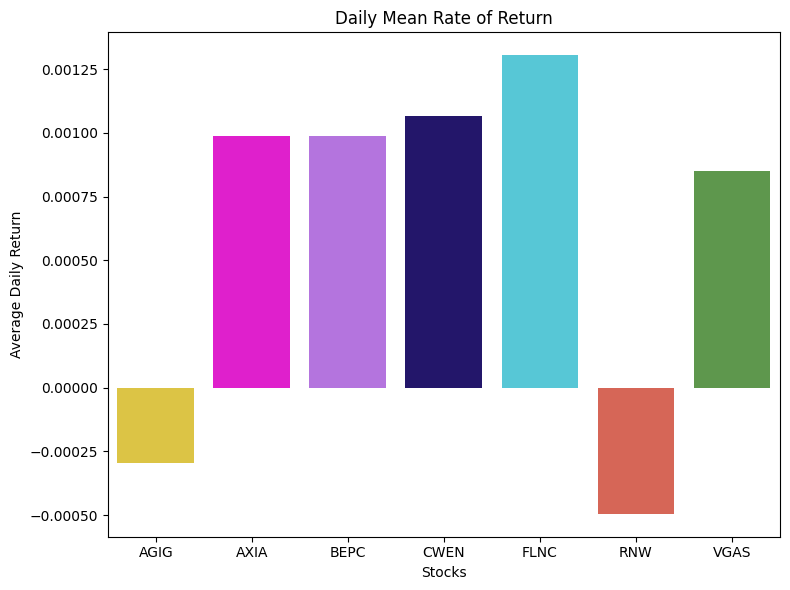

In [8]:
# Plot a bar chart of the average RoRs

plt.figure(figsize=(8,6))
sns.barplot(x='Stock', y='Average Return', hue = 'Stock', data=avg_returns_df, palette=stock_cpalette)
plt.xlabel('Stocks')
plt.ylabel('Average Daily Return')
plt.title('Daily Mean Rate of Return')

plt.tight_layout()
plt.savefig('dailymeanRoR.png', bbox_inches='tight')
plt.show()
plt.close()

Abundia Global Impact Group Inc. (**`AGIG`**) has the **lowest** average daily rate of return (**`RoR`**) among the stocks, while ReNew Energy Global Plc (**`RNW`**) has a **negative** average daily RoR. This suggests these two stocks have **underperformed** over the last two years. Fluence Energy, Inc. (**`FLNC`**) has the **highest** average daily RoR, making it the **top performer** out of the stocks **based on recent daily returns**.

### Variance

In [9]:
# Calculate variance

daily_var = stock_data_daily_returns.var()

# Create a dataframe to make plotting easier

daily_var_df = daily_var.reset_index()
daily_var_df.columns = ['Stock', 'Daily Variance']

daily_var_df

,Stock,Daily Variance
0,AGIG,0.009906
1,AXIA,0.000501
2,BEPC,0.000473
3,CWEN,0.000351
4,FLNC,0.003707
5,RNW,0.000629
6,VGAS,0.002811


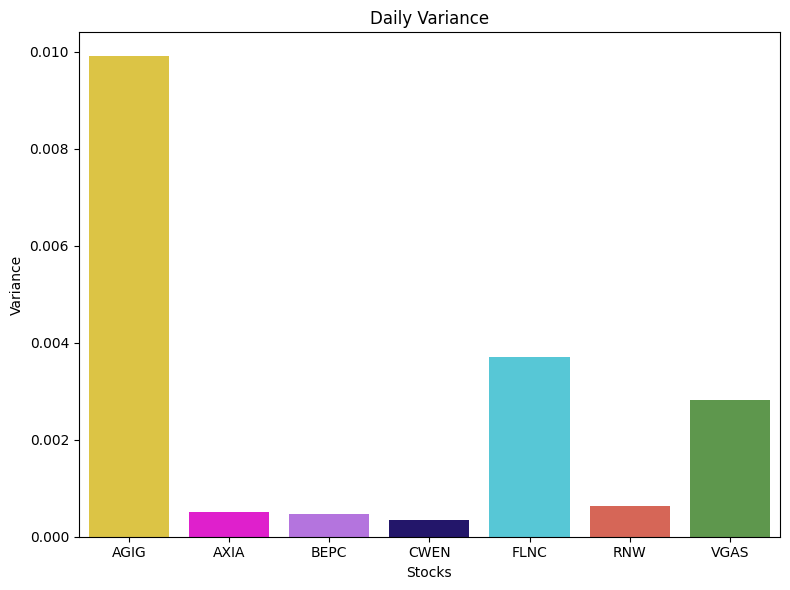

In [10]:
# Plot a bar chart of daily variance

plt.figure(figsize=(8,6))
sns.barplot(x='Stock', y='Daily Variance', hue = 'Stock', data=daily_var_df, palette=stock_cpalette)
plt.xlabel('Stocks')
plt.ylabel('Variance')
plt.title('Daily Variance')

plt.tight_layout()
plt.savefig('dailyvar.png', bbox_inches='tight')
plt.show()
plt.close()

Abundia Global Impact Group Inc. (**`AGIG`**) has the **highest daily variance** meaning its returns fluctuate the most and it is the **riskiest** among the seven stocks. Clearway Energy, Inc. (**`CWEN`**) has the **lowest daily variance** indicating more stable returns and **lower risk**. Brookfield Renewable Corporation (**`BEPC`**), AXIA Energia SA (**`AXIA`**) and ReNew Energy Global Plc (**`RNW`**) also show low variance and a **similar stability**. Although Fluence Energy, Inc. (**`FLNC`**) has a the second highest daily variance among the seven stocks, it is **less volatile** than Abundia Global Impact Group Inc. (**`AGIG`**) at a variance of 0.004, and had the **highest average daily rate of return**, which may appeal to more **risk-tolerant** investors.

### Standard Deviation

In [11]:
# Calculate standard deviation

daily_std = stock_data_daily_returns.std()

# Combine with average return in a dataframe for comparison

avgR_stdD = pd.DataFrame({
    'Stock': avg_returns.index,
    'Average Return': avg_returns.values,
    'Standard Deviation': daily_std.values
})
avgR_stdD

,Stock,Average Return,Standard Deviation
0,AGIG,-0.000295,0.099529
1,AXIA,0.000988,0.022375
2,BEPC,0.000988,0.021747
3,CWEN,0.001066,0.018730
4,FLNC,0.001305,0.060884
5,RNW,-0.000495,0.025075
6,VGAS,0.000850,0.053019


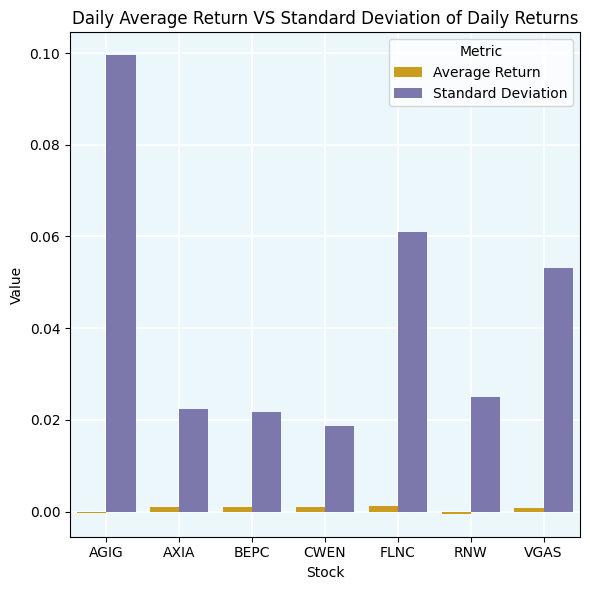

In [12]:
# Convert dataframe to long format for seaborn

avgR_stdD_long = avgR_stdD.melt(id_vars='Stock', var_name='Metric', value_name='Value')

# Plot seaborn bar plot

plt.figure(figsize=(6,6))
sns.barplot(data=avgR_stdD_long, x='Stock', y='Value', hue='Metric', palette='Dark2_r', zorder=2)
plt.title('Daily Average Return VS Standard Deviation of Daily Returns')
plt.xlabel('Stock')
plt.ylabel('Value')
plt.grid(which='both', axis='both', color='white', linewidth=1.25, zorder=0)
plt.gca().set_facecolor('#EBF7FA') 

plt.tight_layout()
plt.savefig('dailyavgRetvsSTDofdailyavgRet.png', bbox_inches='tight')
plt.show()
plt.close()

Overall, Abundia Global Impact Group Inc. (**`AGIG`**) has the highest standard deviation of daily returns, and a negative average return as of the past two years, making it a high-risk and unreliable-return stock to invest in. Abundia Global Impact Group Inc. (**`AGIG`**) and ReNew Energy Global Plc (**`RNW`**) both have negative average returns and are relatively risky making them less attractive.

The stocks with the highest average returns are Fluence Energy, Inc. (**`FLNC`**), Clearway Energy, Inc. (**`CWEN`**) and Brookfield Renewable Corporation (**`BEPC`**) in that order. Fluence Energy, Inc. (**`FLNC`**) has the highest standard deviation out of the three, showing the most variation in daily returns, which makes it the riskiest out of the three stocks with the highest returns. Clearway Energy, Inc. (**`CWEN`**) and Brookfield Renewable Corporation (**`BEPC`**) have higher average returns and lower standard deviations, which suggests better risk-adjusted performance.

### Correlation

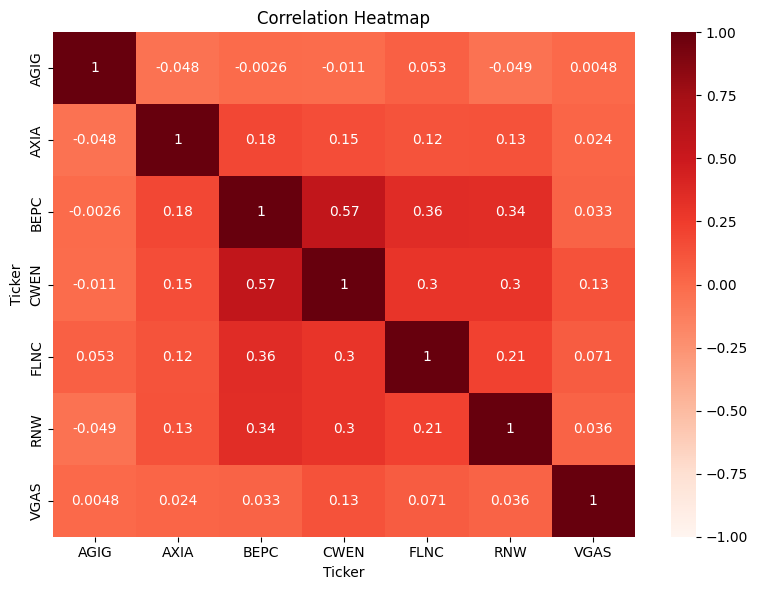

In [13]:
# Calculate correlation between stocks

stocks_corr = stock_data_daily_returns.corr()

# Plot heatmap of correlations between stocks

plt.figure(figsize=(8,6))
sns.heatmap(stocks_corr, annot=True, cmap='Reds', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')

plt.tight_layout()
plt.savefig('corrheatmap.png', bbox_inches='tight')
plt.show()
plt.close()

Most correlation values between the stocks are near 0, which indicates that the stocks **do not move in the same direction much**.
Some pairs such as Brookfield Renewable Corporation (**`BEPC`**) and Clearway Energy, Inc. (**`CWEN`**) (0.56) have a **moderate positive correlation**, so they move together to some extent.
Some correlation values are **slightly negative**, such as most of the stocks with Abundia Global Impact Group Inc. (**`AGIG`**), meaning those stocks sometimes **move in opposite directions**, though by **very little**.
Overall, the stocks are **not strongly related** and combining them in a portfolio would **reduce risk** through diversification.

# **Portfolio Optimisation**

### Efficient Frontier

In [14]:
# Define functions to plot a set of portfolios and the efficient frontier

def return_portfolios(expected_returns, cov_matrix):
    port_returns = []
    port_volatility = []
    stock_weights = []
    
    selected = (expected_returns.axes)[0]
    
    num_assets = len(selected) 
    num_portfolios = 10000
    
    for single_portfolio in range(num_portfolios):
        weights = np.random.random(num_assets)
        weights /= np.sum(weights)
        returns = np.dot(weights, expected_returns)
        volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
        port_returns.append(returns)
        port_volatility.append(volatility)
        stock_weights.append(weights)
    
    portfolio = {'Returns': port_returns,
                 'Volatility': port_volatility}
    
    for counter,symbol in enumerate(selected):
        portfolio[symbol +' Weight'] = [Weight[counter] for Weight in stock_weights]
    
    df = pd.DataFrame(portfolio)
    
    column_order = ['Returns', 'Volatility'] + [stock+' Weight' for stock in selected]
    
    df = df[column_order]
   
    return df

def optimal_portfolio(returns):
    n = returns.shape[1]
    returns = np.transpose(returns.values)

    N = 100
    mus = [10**(5.0 * t/N - 1.0) for t in range(N)]

    # Convert to cvxopt matrices
    S = opt.matrix(np.cov(returns))
    pbar = opt.matrix(np.mean(returns, axis=1))

    # Create constraint matrices
    G = -opt.matrix(np.eye(n))   # negative n x n identity matrix
    h = opt.matrix(0.0, (n ,1))
    A = opt.matrix(1.0, (1, n))
    b = opt.matrix(1.0)

    # Calculate efficient frontier weights using quadratic programming
    portfolios = [solvers.qp(mu*S, -pbar, G, h, A, b)['x']
                  for mu in mus]
    # Calculate risks and returns for frontier
    returns = [blas.dot(pbar, x) for x in portfolios]
    risks = [np.sqrt(blas.dot(x, S*x)) for x in portfolios]
    # Calculate the 2nd degree polynomial of the frontier curve
    m1 = np.polyfit(returns, risks, 2)
    x1 = np.sqrt(m1[2] / m1[0])
    # Calculate optimal portfolio
    wt = solvers.qp(opt.matrix(x1 * S), -pbar, G, h, A, b)['x']
    return np.asarray(wt), returns, risks

Due to **high volatility and negative average return**, Abundia Global Impact Group Inc. (**`AGIG`**) and ReNew Energy Global Plc (**`RNW`**) will be **excluded** from the final recommended portfolios which will be generated in the following steps.

In [15]:
# Remove rows with NaN or infinite values
clean_returns = stock_data_daily_returns.replace([np.inf, -np.inf], np.nan).dropna()

# Remove AGIG and RNW
clean_returns = clean_returns.drop(['AGIG', 'RNW'], axis=1)

# Find the expected returns and covariance matrix

expected_returns = clean_returns.mean()
cov_matrix = clean_returns.cov()

# Use function to find the efficient frontier

weights, frontier_returns, frontier_risks = optimal_portfolio(clean_returns)

# Use function to generate 10,000 portfolios 

df_portfolios = return_portfolios(expected_returns, cov_matrix)
df_portfolios.head()

     pcost       dcost       gap    pres   dres
 0: -1.0167e-03 -1.0012e+00  1e+00  2e-16  3e+00
 1: -1.0167e-03 -1.1229e-02  1e-02  2e-16  3e-02
 2: -1.0202e-03 -1.3268e-03  3e-04  2e-16  8e-04
 3: -1.1063e-03 -1.1797e-03  7e-05  1e-16  3e-19
 4: -1.1262e-03 -1.1364e-03  1e-05  9e-17  5e-19
 5: -1.1336e-03 -1.1340e-03  3e-07  1e-16  4e-19
 6: -1.1338e-03 -1.1338e-03  3e-09  2e-16  4e-19
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -1.0139e-03 -1.0012e+00  1e+00  1e-16  3e+00
 1: -1.0139e-03 -1.1220e-02  1e-02  7e-17  3e-02
 2: -1.0173e-03 -1.3174e-03  3e-04  5e-17  8e-04
 3: -1.0950e-03 -1.1617e-03  7e-05  1e-16  6e-19
 4: -1.1137e-03 -1.1260e-03  1e-05  2e-16  3e-19
 5: -1.1223e-03 -1.1226e-03  4e-07  2e-16  3e-19
 6: -1.1224e-03 -1.1224e-03  4e-09  2e-16  3e-19
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -1.0108e-03 -1.0012e+00  1e+00  2e-16  3e+00
 1: -1.0108e-03 -1.1210e-02  1e-02  1e-16  3e-02
 2: -1.0141e-03 -1.3068e

,Returns,Volatility,AXIA Weight,BEPC Weight,CWEN Weight,FLNC Weight,VGAS Weight
0,0.001015,0.017537,0.191168,0.309010,0.252466,0.090715,0.156642
1,0.001093,0.022785,0.319252,0.099810,0.266800,0.280621,0.033518
2,0.000987,0.017001,0.288165,0.483992,0.043599,0.046865,0.137379
3,0.001030,0.021491,0.151024,0.001434,0.438186,0.140370,0.268986
4,0.000995,0.018975,0.010681,0.319186,0.433669,0.012089,0.224375


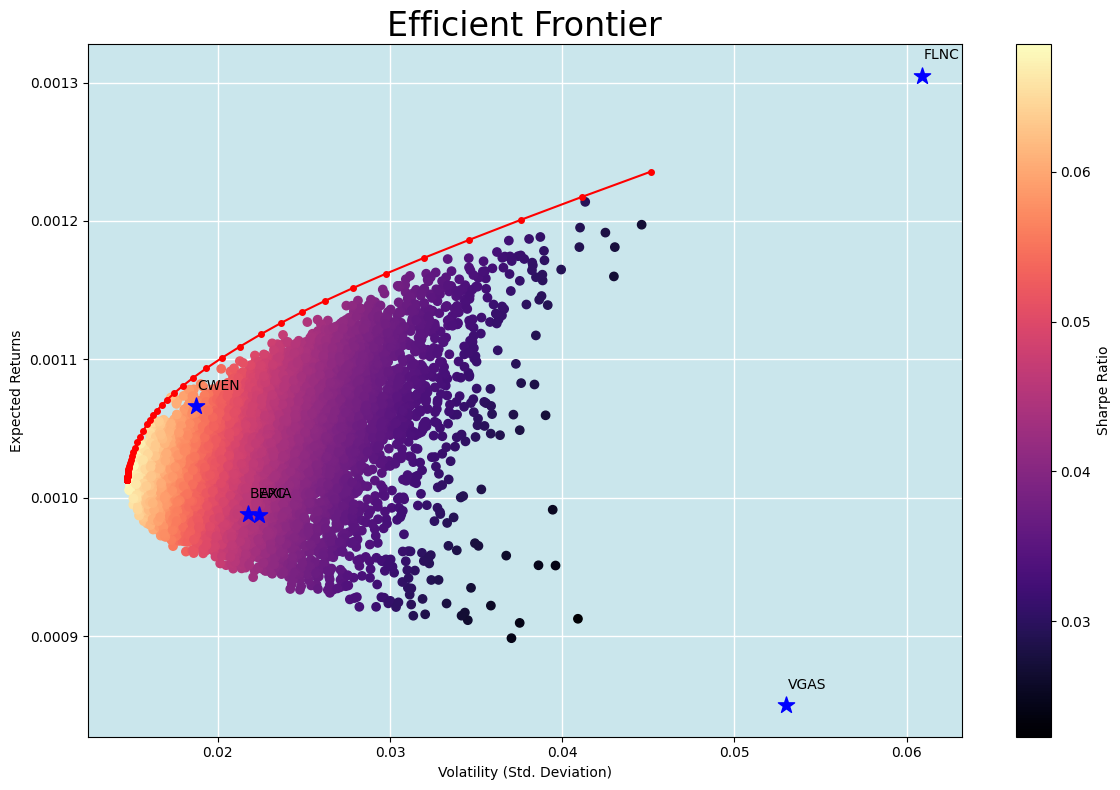

In [19]:
# Plot the portfolios onto a scatterplot

plt.figure(figsize=(12,8))
plt.grid(color='white', linewidth=1, zorder=0)  
plt.scatter(
    df_portfolios['Volatility'], 
    df_portfolios['Returns'], 
    c=df_portfolios['Returns']/df_portfolios['Volatility'], 
    cmap='magma', 
    zorder=3
)
plt.xlabel('Volatility (Risk)')
plt.ylabel('Expected Return')
plt.title('10,000 Simulated Portfolios')
plt.colorbar(label='Sharpe Ratio')

# Plot the efficient frontier

plt.plot(frontier_risks, frontier_returns, 'r-o', zorder=4, markersize=4)

# Plot the standard deviation of each individual stock

indv_stock_std = np.sqrt(np.diagonal(cov_matrix))
exc_avg_returns = avg_returns.drop(['AGIG', 'RNW'])
plt.scatter(indv_stock_std, exc_avg_returns, marker='*', color='blue', s=150, zorder=5)
for i, txt in enumerate(clean_returns.keys()):
    plt.annotate(txt, (indv_stock_std[i], exc_avg_returns.iloc[i]), size=10, xytext=(1,12), ha='left', textcoords='offset points')
plt.xlabel('Volatility (Std. Deviation)')
plt.ylabel('Expected Returns')
plt.title('Efficient Frontier', fontsize=24)

plt.gca().set_facecolor('#CAE6EC')
plt.tight_layout()
plt.savefig('efficientfrontier.png', bbox_inches='tight')
plt.show()
plt.close()

### Maximum Sharpe Ratio

The Sharpe Ratio measures how much extra reward you get for each unit of risk in a portfolio. A portfolio with a higher Sharpe ratio means more return for the same amount of risk, and is a better choice for investment.

In [25]:
# Calculate the Sharpe ratio for each portfolio

df_portfolios['Sharpe'] = df_portfolios['Returns'] / df_portfolios['Volatility']

# Find the index of the maximum Sharpe ratio and get the portfolio

max_sharpe_idx = df_portfolios['Sharpe'].idxmax()
max_sharpe_portfolio = df_portfolios.loc[max_sharpe_idx]
max_sharpe_portfolio_df = pd.DataFrame(max_sharpe_portfolio).T
weight_cols = [col for col in max_sharpe_portfolio_df.columns if 'Weight' in col]
max_sharpe_portfolio_df[weight_cols] = max_sharpe_portfolio_df[weight_cols].round(4)

max_sharpe_portfolio_df

,Returns,Volatility,AXIA Weight,BEPC Weight,CWEN Weight,FLNC Weight,VGAS Weight,Sharpe
4618,0.001021,0.014908,0.3015,0.2169,0.4419,0.0092,0.0305,0.068495


### Maximum return

In [21]:
max_return_idx = df_portfolios['Returns'].idxmax()
max_return_portfolio = df_portfolios.loc[max_return_idx]
max_return_portfolio_df = max_return_portfolio.to_frame().T
weight_cols = [col for col in max_return_portfolio_df.columns if 'Weight' in col]
max_return_portfolio_df[weight_cols] = max_return_portfolio_df[weight_cols].round(4)


max_return_portfolio_df

,Returns,Volatility,AXIA Weight,BEPC Weight,CWEN Weight,FLNC Weight,VGAS Weight,Sharpe
2338,0.001214,0.041335,0.0056,0.0037,0.3327,0.6389,0.0191,0.029366


This portfolio has the highest expected return, but also a high volatility. It is only suitable for very risk-tolerant investors willing to accept large fluctuations and high risk.

### Minimum Risk

In [22]:
min_risk_idx = df_portfolios['Volatility'].idxmin()
min_risk_portfolio = df_portfolios.loc[min_risk_idx]
min_risk_portfolio_df = min_risk_portfolio.to_frame().T
weight_cols = [col for col in min_risk_portfolio_df.columns if 'Weight' in col]
min_risk_portfolio_df[weight_cols] = min_risk_portfolio_df[weight_cols].round(4)

min_risk_portfolio_df

,Returns,Volatility,AXIA Weight,BEPC Weight,CWEN Weight,FLNC Weight,VGAS Weight,Sharpe
11,0.001006,0.014845,0.3334,0.243,0.3452,0.0032,0.0751,0.067739


While this portfolio has the lowest volatility it has a lower return. It is better suited for conservative investors who want stability and a lower chance of loss.

### Median Risk-Return Portfolio

In [23]:
median_idx = ((df_portfolios['Returns'] - df_portfolios['Returns'].median()).abs() +
              (df_portfolios['Volatility'] - df_portfolios['Volatility'].median()).abs()).idxmin()
median_portfolio = df_portfolios.loc[median_idx]
median_portfolio_df = median_portfolio.to_frame().T
weight_cols = [col for col in median_portfolio_df.columns if 'Weight' in col]
median_portfolio_df[weight_cols] = median_portfolio_df[weight_cols].round(4)

median_portfolio_df

,Returns,Volatility,AXIA Weight,BEPC Weight,CWEN Weight,FLNC Weight,VGAS Weight,Sharpe
3048,0.001041,0.022587,0.238,0.3505,0.0103,0.2364,0.1648,0.046087


This portfolio balances risk and return, settling between growth and stability. Out of the three portfolios, it is the most diversified in terms of the weights of the stocks. 